# Libraries

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
                        "text.usetex": True,
                        "font.family": "serif",
                        "font.serif": ["Times New Roman"],
                        "axes.unicode_minus": False,
                    })
# from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.max_columns', None)
import numpy as np

# Read dataset

In [57]:
df = pd.read_excel('data_models.xlsx', sheet_name='dataset')
df.columns = df.columns.str.lower().str.replace(' ', '-')
df.head()

,autor,diâmetro-da-armadura-f-(mm),número-de-barras-em-uma-camada,espaçamento-entre-as-barras-(mm),resistência-à-tração-do-concreto-fctm-(mpa),cobrimento-c-(mm),distância-ao-centro-de-gravidade-da-armadura-d'-(mm),taxa-de-armadura-r,tensão-na-armadura-(mpa),tension-stiffening-(b),tensão-na-armadura-na-fissuração-do-concreto-(ssr),ss---bssr-(mpa),wexp-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.515850,90.135975,185.314362,0.16
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.372710,90.135975,270.657365,0.23
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.334820,90.135975,284.102901,0.24
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.176945,90.135975,347.370061,0.27
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.052750,90.135975,454.409433,0.35


# Dataset statistics

### Summary

In [58]:
df_x = df.describe().T
df_x.drop(columns=["count"], inplace=True)
df_x

,mean,std,min,25%,50%,75%,max
diâmetro-da-armadura-f-(mm),17.910643,6.272794,9.520000,12.000000,16.000000,20.000000,35.800000
número-de-barras-em-uma-camada,2.497076,1.365148,1.000000,2.000000,2.000000,3.750000,9.000000
espaçamento-entre-as-barras-(mm),63.710341,46.755024,12.000000,40.000000,46.000000,69.800000,296.000000
resistência-à-tração-do-concreto-fctm-(mpa),3.096916,0.514515,2.384602,2.800000,2.920876,3.269000,5.308474
cobrimento-c-(mm),32.647807,10.871746,12.800000,25.000000,30.000000,40.000000,70.000000
distância-ao-centro-de-gravidade-da-armadura-d'-(mm),43.761988,12.119438,23.900000,35.000000,40.950000,49.100000,94.500000
taxa-de-armadura-r,0.050929,0.042848,0.007960,0.017479,0.044148,0.065231,0.221883
tensão-na-armadura-(mpa),309.432666,91.257643,106.512655,244.795079,297.459578,367.776857,628.000000
tension-stiffening-(b),0.360226,0.171707,0.000000,0.242154,0.387113,0.485401,0.600000
tensão-na-armadura-na-fissuração-do-concreto-(ssr),138.207936,96.501844,40.180305,65.347574,90.135975,207.320634,372.604414


### Latex export

In [59]:
latex_table = df_x.to_latex(
                                index=True, 
                                float_format="%.3f",
                                caption="Model statistics summary.",
                                label="tab:model_stats_summary",
                                longtable=False,
                                escape=False  
                            )
print(latex_table)

\begin{table}
\caption{Model statistics summary.}
\label{tab:model_stats_summary}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
diâmetro-da-armadura-f-(mm) & 17.911 & 6.273 & 9.520 & 12.000 & 16.000 & 20.000 & 35.800 \\
número-de-barras-em-uma-camada & 2.497 & 1.365 & 1.000 & 2.000 & 2.000 & 3.750 & 9.000 \\
espaçamento-entre-as-barras-(mm) & 63.710 & 46.755 & 12.000 & 40.000 & 46.000 & 69.800 & 296.000 \\
resistência-à-tração-do-concreto-fctm-(mpa) & 3.097 & 0.515 & 2.385 & 2.800 & 2.921 & 3.269 & 5.308 \\
cobrimento-c-(mm) & 32.648 & 10.872 & 12.800 & 25.000 & 30.000 & 40.000 & 70.000 \\
distância-ao-centro-de-gravidade-da-armadura-d'-(mm) & 43.762 & 12.119 & 23.900 & 35.000 & 40.950 & 49.100 & 94.500 \\
taxa-de-armadura-r & 0.051 & 0.043 & 0.008 & 0.017 & 0.044 & 0.065 & 0.222 \\
tensão-na-armadura-(mpa) & 309.433 & 91.258 & 106.513 & 244.795 & 297.460 & 367.777 & 628.000 \\
tension-stiffening-(b) & 0.360 & 0.172 & 0.000 & 0.242 & 0.387 &

# Predictive crack models

### Read dataset

In [60]:
df = pd.read_excel('data_models.xlsx', sheet_name='models')
df.columns = df.columns.str.lower().str.replace(' ', '-')
df.head()

,wexp-(mm),fib-model-code-2010,fib-model-code-2020,eurocode-2,nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956),leonhardt-(1977),desayi-ganesan-(1985),oh-kang-(1987),caldas-(1997),gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020)
0,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007
1,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266
2,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096
3,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958
4,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382


In [61]:
cols = df.columns.tolist()
cols.pop(0)
cols_models = cols.copy()
cols_models

['fib-model-code-2010',
 'fib-model-code-2020',
 'eurocode-2',
 'nbr-6118---wk1---fissuração-estabilizada',
 'nbr-6118---wk2---fissuração-não-estabilizada',
 'clark-(1956)',
 'leonhardt-(1977)',
 'desayi-ganesan-(1985)',
 'oh-kang-(1987)',
 'caldas-(1997)',
 'gergely-e-lutz-(1968)',
 '-b--variável-e_menor_zero_seis',
 'equação-(15)-do-artigo-de-belarbi-e-hsu-(1994)',
 'beta-conforme-fields-e-bischoff-(2004)',
 'slip-de-yuan-et-al-(2025)',
 'slip-de-biscaia-e-soares-(2020)']

### Numerical models statistics: $w_{model}/ w_{exp}$

In [62]:
for coluna in cols_models:
    df[f'{coluna}-div-wexp-(mm)'] = df[coluna] / df['wexp-(mm)']
    df[f'abs_error-{coluna}'] = abs(df[coluna] - df['wexp-(mm)'])
df.head()

,wexp-(mm),fib-model-code-2010,fib-model-code-2020,eurocode-2,nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956),leonhardt-(1977),desayi-ganesan-(1985),oh-kang-(1987),caldas-(1997),gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020),fib-model-code-2010-div-wexp-(mm),abs_error-fib-model-code-2010,fib-model-code-2020-div-wexp-(mm),abs_error-fib-model-code-2020,eurocode-2-div-wexp-(mm),abs_error-eurocode-2,nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm),abs_error-nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada-div-wexp-(mm),abs_error-nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956)-div-wexp-(mm),abs_error-clark-(1956),leonhardt-(1977)-div-wexp-(mm),abs_error-leonhardt-(1977),desayi-ganesan-(1985)-div-wexp-(mm),abs_error-desayi-ganesan-(1985),oh-kang-(1987)-div-wexp-(mm),abs_error-oh-kang-(1987),caldas-(1997)-div-wexp-(mm),abs_error-caldas-(1997),gergely-e-lutz-(1968)-div-wexp-(mm),abs_error-gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis-div-wexp-(mm),abs_error--b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994)-div-wexp-(mm),abs_error-equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004)-div-wexp-(mm),abs_error-beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025)-div-wexp-(mm),abs_error-slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020)-div-wexp-(mm),abs_error-slip-de-biscaia-e-soares-(2020)
0,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007,0.785838,0.034266,0.538496,0.073841,0.783073,0.034708,1.640424,0.102468,0.983623,0.002620,1.131289,0.021006,1.852338,0.136374,1.954276,0.152684,1.162307,0.025969,0.812485,0.030002,1.509550,0.081528,0.638311,0.057870,0.937226,0.010044,0.728538,0.043434,0.685535,0.050314,0.512541,0.077993
1,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266,0.769488,0.053018,0.639681,0.082873,0.766780,0.053641,1.497778,0.114489,1.178744,0.041111,1.062446,0.014363,1.943692,0.217049,1.784339,0.180398,1.113929,0.026204,0.759763,0.055254,1.378284,0.087005,0.829489,0.039217,0.888470,0.025652,0.857774,0.032712,0.840549,0.036674,0.679418,0.073734
2,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096,0.766992,0.055922,0.648201,0.084432,0.764293,0.056570,1.482691,0.115846,1.205338,0.049281,1.054729,0.013135,1.945832,0.227000,1.766365,0.183928,1.108035,0.025928,0.753923,0.059059,1.364401,0.087456,0.846073,0.036942,0.883550,0.027948,0.866837,0.031959,0.855420,0.034699,0.696232,0.072904
3,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958,0.810256,0.051231,0.729030,0.073162,0.807405,0.052001,1.523584,0.141368,1.431836,0.116596,1.096379,0.026022,2.083324,0.292498,1.815083,0.220072,1.161007,0.043472,0.782342,0.058768,1.402032,0.108549,0.974328,0.006931,0.926442,0.019861,0.960621,0.010632,0.982303,0.004778,0.822067,0.048042
4,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382,0.818784,0.063426,0.792864,0.072498,0.815903,0.064434,1.485395,0.169888,1.764202,0.267471,1.085279,0.029848,2.121938,0.392678,1.769586,0.269355,1.161136,0.056398,0.772678,0.079563,1.366889,0.128411,1.086752,0.030363,0.891058,0.038130,1.013742,0.004810,1.111280,0.038948,0.966805,0.011618


### Summary

In [63]:
cols_models.append('wexp-(mm)')
df_models = df.drop(columns=cols_models)
desc = df_models.describe()
skew = df_models.skew()
kurt = df_models.kurtosis()
desc.loc['skewness'] = skew
desc.loc['kurtosis'] = kurt
df_x = desc.T
df_x.drop(columns=["count"], inplace=True)
df_x

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fib-model-code-2010-div-wexp-(mm),0.860696,0.275184,0.035845,0.669205,0.831805,1.063259,1.561775,0.090073,0.062116
abs_error-fib-model-code-2010,0.070672,0.070066,0.000071,0.024897,0.050514,0.087703,0.458577,2.139408,5.817605
fib-model-code-2020-div-wexp-(mm),0.852736,0.254702,0.192985,0.674356,0.848713,0.995123,1.574500,0.300891,0.114783
abs_error-fib-model-code-2020,0.066258,0.060308,0.000046,0.024329,0.049223,0.089936,0.394463,1.780076,4.359520
eurocode-2-div-wexp-(mm),0.911113,0.312953,0.241073,0.721076,0.869290,1.076883,2.020206,0.817655,1.267853
abs_error-eurocode-2,0.072603,0.075149,0.000121,0.024628,0.050411,0.092775,0.444483,2.270803,6.319496
nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm),1.113372,0.337889,0.239873,0.880870,1.151932,1.355376,2.013550,-0.127581,-0.417286
abs_error-nbr-6118---wk1---fissuração-estabilizada,0.077331,0.069489,0.000471,0.032773,0.061733,0.106119,0.456076,2.392144,8.285101
nbr-6118---wk2---fissuração-não-estabilizada-div-wexp-(mm),1.251528,0.622211,0.199315,0.840363,1.127546,1.595437,4.535839,1.475947,4.162280
abs_error-nbr-6118---wk2---fissuração-não-estabilizada,0.120683,0.125277,0.000104,0.031030,0.086926,0.161828,0.777885,2.020321,5.025195


### Latex export

In [64]:
latex_table = df_x.to_latex(
                                index=True, 
                                float_format="%.3f",
                                caption="Model statistics summary.",
                                label="tab:model_stats_summary",
                                longtable=False,
                                escape=False  
                            )
print(latex_table)

\begin{table}
\caption{Model statistics summary.}
\label{tab:model_stats_summary}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max & skewness & kurtosis \\
\midrule
fib-model-code-2010-div-wexp-(mm) & 0.861 & 0.275 & 0.036 & 0.669 & 0.832 & 1.063 & 1.562 & 0.090 & 0.062 \\
abs_error-fib-model-code-2010 & 0.071 & 0.070 & 0.000 & 0.025 & 0.051 & 0.088 & 0.459 & 2.139 & 5.818 \\
fib-model-code-2020-div-wexp-(mm) & 0.853 & 0.255 & 0.193 & 0.674 & 0.849 & 0.995 & 1.575 & 0.301 & 0.115 \\
abs_error-fib-model-code-2020 & 0.066 & 0.060 & 0.000 & 0.024 & 0.049 & 0.090 & 0.394 & 1.780 & 4.360 \\
eurocode-2-div-wexp-(mm) & 0.911 & 0.313 & 0.241 & 0.721 & 0.869 & 1.077 & 2.020 & 0.818 & 1.268 \\
abs_error-eurocode-2 & 0.073 & 0.075 & 0.000 & 0.025 & 0.050 & 0.093 & 0.444 & 2.271 & 6.319 \\
nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm) & 1.113 & 0.338 & 0.240 & 0.881 & 1.152 & 1.355 & 2.014 & -0.128 & -0.417 \\
abs_error-nbr-6118---wk1---fissuração-estabiliz

### Charts

#### Histogram

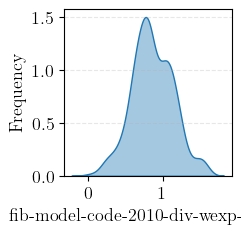

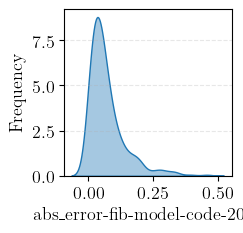

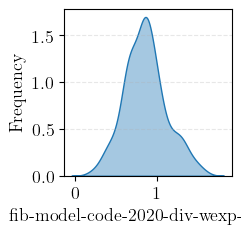

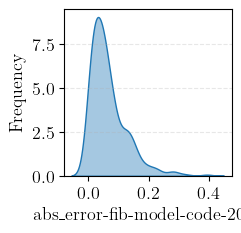

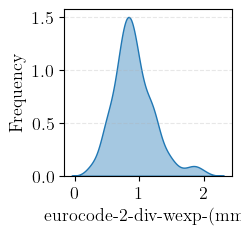

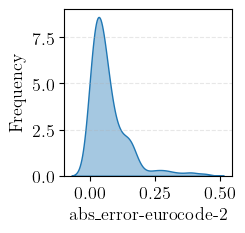

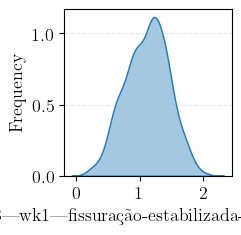

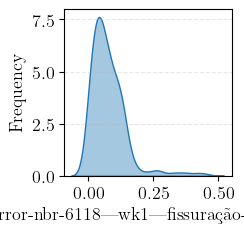

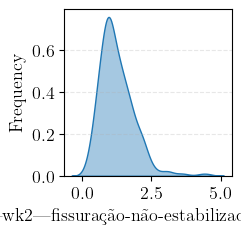

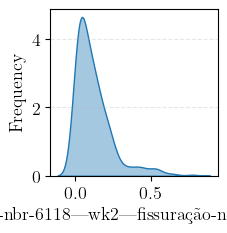

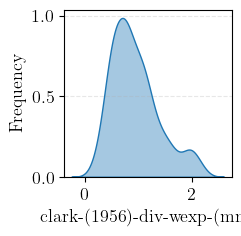

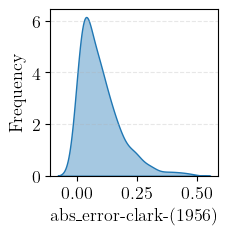

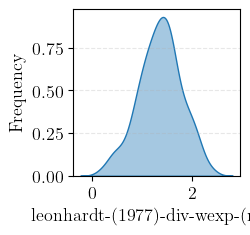

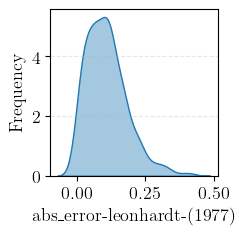

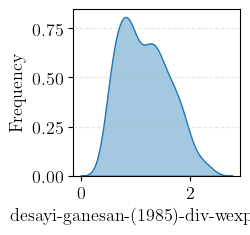

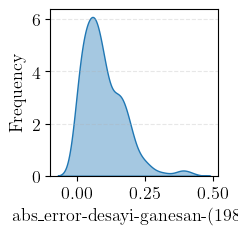

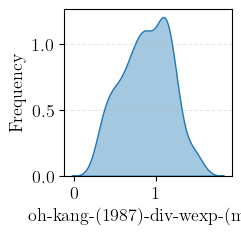

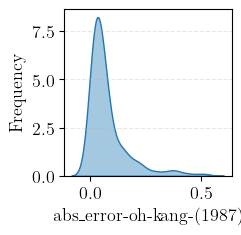

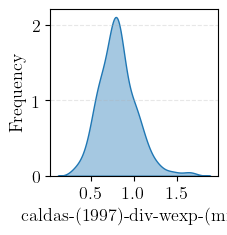

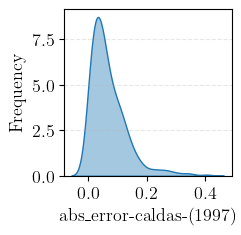

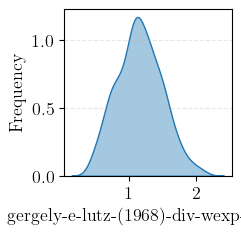

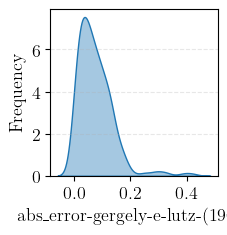

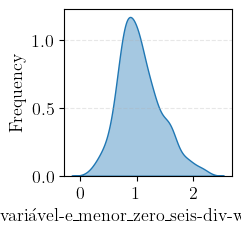

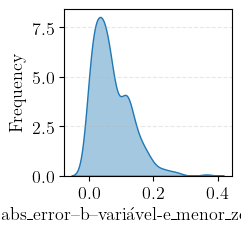

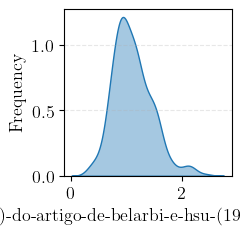

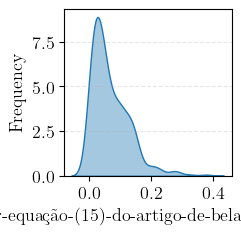

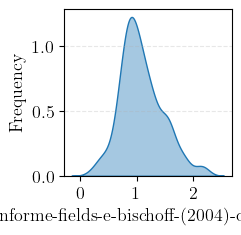

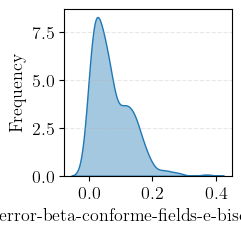

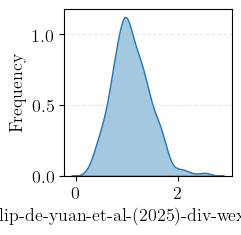

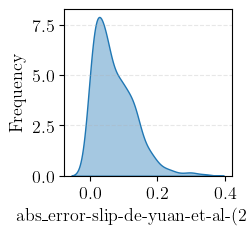

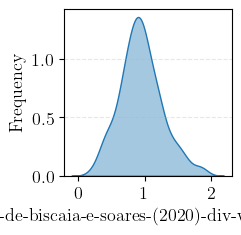

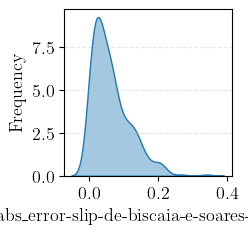

In [65]:
cols_compare = df_models.columns.tolist()
for i in cols_compare:
    ratio_data = df_models[i]
    width_cm = 5.5
    height_cm = 5.5
    inches_per_cm = 1 / 2.54
    width_in = width_cm * inches_per_cm
    height_in = height_cm * inches_per_cm
    y_axis_label = i
    label_size = 13
    axis_size = 13
    label_color = 'black'
    # KDE Plot
    plt.figure(figsize=(width_in, height_in))
    sns.kdeplot(data=ratio_data, fill=True, alpha=0.4)
    plt.tick_params(axis='both', which='major', labelsize=axis_size)
    plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
    plt.ylabel('Frequency', fontsize=label_size, color=label_color)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.savefig(f'z_fig_{i}.png', dpi=600, bbox_inches='tight')
    plt.show()

#### Predict versus Observed

In [66]:
y_val_obs_aux = df['wexp-(mm)'].tolist()
y_val_pre_aux = df['fib-model-code-2010'].tolist()

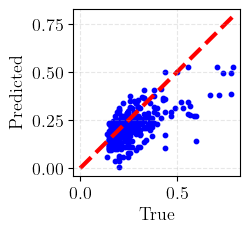

In [ ]:
# Figure dimension
width_cm = 5.5
height_cm = 5.5
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 13
axis_size = 13

label_color = 'black'

# Scatter Plot
point_size = 10
color_scatter = 'blue'
plt.figure(figsize=(width_in, height_in))
plt.scatter(y_val_obs_aux, y_val_pre_aux, s=point_size, c=color_scatter)

# Regression Line
regression_line_color = 'red'
regression_line_style = '--'
regression_line_width = 3
x_line = np.array([0, max(y_val_obs_aux)])
y_line = x_line
plt.plot(x_line, y_line,
         color=regression_line_color,
         linestyle=regression_line_style,
         linewidth=regression_line_width,
         zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(label_x, fontsize=label_size, color=label_color)
plt.ylabel(label_y, fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
# plt.savefig('validation_scatter_train.png', dpi=600)

#### Sort by error

In [ ]:
df['Divs'] = pd.qcut(df['abs_error-fib-model-code-2010'], q=10, labels=False)
df_sort = df.sort_values(by='abs_error-fib-model-code-2010', ascending=False)
df_sort

,wexp-(mm),fib-model-code-2010,fib-model-code-2020,eurocode-2,nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956),leonhardt-(1977),desayi-ganesan-(1985),oh-kang-(1987),caldas-(1997),gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020),fib-model-code-2010-div-wexp-(mm),abs_error-fib-model-code-2010,fib-model-code-2020-div-wexp-(mm),abs_error-fib-model-code-2020,eurocode-2-div-wexp-(mm),abs_error-eurocode-2,nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm),abs_error-nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada-div-wexp-(mm),abs_error-nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956)-div-wexp-(mm),abs_error-clark-(1956),leonhardt-(1977)-div-wexp-(mm),abs_error-leonhardt-(1977),desayi-ganesan-(1985)-div-wexp-(mm),abs_error-desayi-ganesan-(1985),oh-kang-(1987)-div-wexp-(mm),abs_error-oh-kang-(1987),caldas-(1997)-div-wexp-(mm),abs_error-caldas-(1997),gergely-e-lutz-(1968)-div-wexp-(mm),abs_error-gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis-div-wexp-(mm),abs_error--b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994)-div-wexp-(mm),abs_error-equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004)-div-wexp-(mm),abs_error-beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025)-div-wexp-(mm),abs_error-slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020)-div-wexp-(mm),abs_error-slip-de-biscaia-e-soares-(2020),Divisoes
29,0.60,0.141423,0.205537,0.165750,0.143924,0.371668,0.171614,0.287167,0.348955,0.204797,0.193591,0.311815,0.234351,0.221931,0.230290,0.295264,0.260431,0.235705,0.458577,0.342562,0.394463,0.276250,0.434250,0.239873,0.456076,0.619447,0.228332,0.286023,0.428386,0.478611,0.312833,0.581592,0.251045,0.341328,0.395203,0.322651,0.406409,0.519691,0.288185,0.390584,0.365649,0.369885,0.378069,0.383816,0.369710,0.492107,0.304736,0.434051,0.339569,9
40,0.78,0.384845,0.456106,0.335517,0.402771,1.237626,0.302926,0.661738,0.373505,0.350432,0.514817,0.451299,0.513242,0.456106,0.499391,0.913442,0.676814,0.493391,0.395155,0.584751,0.323894,0.430150,0.444483,0.516373,0.377229,1.586700,0.457626,0.388367,0.477074,0.848382,0.118262,0.478853,0.406495,0.449272,0.429568,0.660022,0.265183,0.578588,0.328701,0.658003,0.266758,0.584751,0.323894,0.640245,0.280609,1.171079,0.133442,0.867710,0.103186,9
65,0.72,0.380222,0.439619,0.332799,0.402771,1.237626,0.275533,0.661738,0.341102,0.341695,0.494943,0.417692,0.490242,0.439619,0.477971,0.904063,0.661141,0.528087,0.339778,0.610582,0.280381,0.462221,0.387201,0.559404,0.317229,1.718925,0.517626,0.382685,0.444467,0.919081,0.058262,0.473752,0.378898,0.474577,0.378305,0.687421,0.225057,0.580127,0.302308,0.680892,0.229758,0.610582,0.280381,0.663848,0.242029,1.255643,0.184063,0.918251,0.058859,9
28,0.44,0.103307,0.145347,0.121077,0.108542,0.211388,0.127794,0.212219,0.263168,0.148840,0.143375,0.235158,0.160636,0.163699,0.163111,0.200183,0.171756,0.234788,0.336693,0.330334,0.294653,0.275175,0.318923,0.246685,0.331458,0.480428,0.228612,0.290442,0.312206,0.482317,0.227781,0.598108,0.176832,0.338273,0.291160,0.325852,0.296625,0.534450,0.204842,0.365083,0.279364,0.372044,0.276301,0.370707,0.276889,0.454962,0.239817,0.390355,0.268244,9
69,0.60,0.272119,0.371327,0.319146,0.327208,0.318962,0.280901,0.427475,0.352203,0.209278,0.320974,0.418674,0.400428,0.451779,0.422438,0.416102,0.398169,0.453532,0.327881,0.618878,0.228673,0.531911,0.280854,0.545347,0.272792,0.531604,0.281038,0.468168,0.319099,0.712459,0.172525,0.587006,0.247797,0.348796,0.390722,0.534956,0.279026,0.697790,0.181326,0.667379,0.199572,0.752965,0.148221,0.704063,0.177562,0.693504,0.183898,0.663615,0.201831,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

#### Save sort data

In [70]:
df_sort.to_excel('stats_compare.xlsx')
# tabela = (f'estatistica_{modelo}.xlsx')
# with pd.ExcelWriter(tabela, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
#     df[df['Divisoes'] == 9].describe().to_excel(writer, sheet_name='35 maiores erros (9 div)')
#     df[df['Divisoes'] == 8].describe().to_excel(writer, sheet_name='34 erros (8 div)')
#     df[df['Divisoes'] == 7].describe().to_excel(writer, sheet_name='34 erros (7 div)')
#     df[df['Divisoes'] == 6].describe().to_excel(writer, sheet_name='34 erros (6 div)')
#     df[df['Divisoes'] == 5].describe().to_excel(writer, sheet_name='34 erros (5 div)')
#     df[df['Divisoes'] == 4].describe().to_excel(writer, sheet_name='34 erros (4 div)')
#     df[df['Divisoes'] == 3].describe().to_excel(writer, sheet_name='34 erros (3 div)')
#     df[df['Divisoes'] == 2].describe().to_excel(writer, sheet_name='34 erros (2 div)')
#     df[df['Divisoes'] == 1].describe().to_excel(writer, sheet_name='33 erros (1 div)')
#     df[df['Divisoes'] == 0].describe().to_excel(writer, sheet_name='36 erros (0 div)')